# NB06: Synthesis Figures

**Purpose**: Combine Pagel's λ results (NB04) and PGLS results (NB05) into publication-quality
multi-panel figures that tell the complete story:

1. **How conserved are niche breadth and metal AMR traits?** → λ heatmap (trait × domain)
2. **Does metal AMR diversity predict niche breadth beyond phylogeny?** → PGLS forest plot
3. **What does the strongest effect look like?** → Annotated scatter (metal type diversity vs B_std)

**Inputs**:
- `data/pagel_lambda_results.csv` — λ, p-value per trait × domain (NB04)
- `data/pgls_results.csv` — β, SE, p per model (NB05)
- `data/pgls_multi_results.csv` — multi-predictor coefficients (NB05)
- `data/pgls_subset.csv` — 606-genus filtered trait table (NB05)

**Outputs**:
- `figures/fig1_lambda_heatmap.png` — Pagel's λ heatmap
- `figures/fig2_pgls_forest.png` — PGLS forest plot (all 6 simple models)
- `figures/fig3_synthesis.png` — 2-panel synthesis figure (heatmap + forest)
- `figures/fig4_metal_types_scatter.png` — annotated metal type vs B_std scatter

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from scipy import stats as sp_stats

DATA    = Path('../data')
FIGURES = Path('../figures')
FIGURES.mkdir(exist_ok=True)

# ── Plotting style ───────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':     'DejaVu Sans',
    'font.size':       9,
    'axes.labelsize':  9,
    'axes.titlesize':  10,
    'legend.fontsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi':      150,
    'savefig.dpi':     300,
    'savefig.bbox':    'tight',
})

print('Imports ready.')
print(f'  DATA:    {DATA.resolve()}')
print(f'  FIGURES: {FIGURES.resolve()}')

Imports ready.
  DATA:    /home/hmacgregor/BERIL-research-observatory/projects/microbeatlas_metal_ecology/data
  FIGURES: /home/hmacgregor/BERIL-research-observatory/projects/microbeatlas_metal_ecology/figures


## 1. Load results data

In [2]:
# ── Pagel's λ results ────────────────────────────────────────────────────────
lam_df = pd.read_csv(DATA / 'pagel_lambda_results.csv')
print(f'Pagel lambda results: {len(lam_df)} rows')
print(lam_df[['label', 'trait', 'n_taxa', 'lambda', 'p_value']].to_string(index=False))

# ── PGLS results ─────────────────────────────────────────────────────────────
pgls = pd.read_csv(DATA / 'pgls_results.csv')
multi = pd.read_csv(DATA / 'pgls_multi_results.csv')
pgls_sub = pd.read_csv(DATA / 'pgls_subset.csv')
print(f'\nPGLS simple results: {len(pgls)} rows')
print(f'PGLS multi results:  {len(multi)} rows')
print(f'PGLS subset:         {len(pgls_sub):,} genera')

Pagel lambda results: 10 rows
   label                     trait  n_taxa   lambda       p_value
Bacteria         mean_levins_B_std    1264 0.787081 7.866506e-102
 Archaea         mean_levins_B_std     132 0.196774  1.094458e-05
Bacteria               mean_n_envs    1264 0.909406 1.444893e-157
 Archaea               mean_n_envs     132 0.897895  4.616495e-14
Bacteria              is_nitrifier    2286 0.938531 2.525155e-102
 Archaea              is_nitrifier     132 0.999927  2.470369e-51
Bacteria mean_n_metal_amr_clusters     606 0.259837  6.098142e-28
Bacteria  mean_metal_core_fraction     606 0.440538  1.816085e-08
Bacteria        mean_n_metal_types     606 0.335043  1.112193e-23
 Archaea mean_n_metal_amr_clusters      48 0.000073  1.000000e+00

PGLS simple results: 6 rows
PGLS multi results:  3 rows
PGLS subset:         606 genera


In [3]:
# ── Shared label maps ────────────────────────────────────────────────────────
TRAIT_LABELS = {
    'mean_levins_B_std':         "Niche breadth\n(Levins' B_std)",
    'mean_n_envs':               'Habitat range\n(# environments)',
    'is_nitrifier':              'Nitrification\n(functional trait)',
    'mean_n_metal_amr_clusters': 'Metal AMR genes\n(cluster count)',
    'mean_metal_core_fraction':  'Metal AMR\n(core fraction)',
    'mean_n_metal_types':        'Metal type\ndiversity',
}

PRED_LABELS = {
    'mean_n_metal_amr_clusters_z': 'AMR clusters (z)',
    'mean_metal_core_fraction_z':  'Core AMR fraction (z)',
    'mean_n_metal_types_z':        'Metal type diversity (z)',
}

RESP_LABELS = {
    'mean_levins_B_std': "Levins' B_std",
    'mean_n_envs':       'Environments detected',
}

BONFERRONI = 0.05 / 6

# Add significance annotation column
def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

pgls['sig']  = pgls['p_value'].map(sig_stars)
multi['sig'] = multi['p_value'].map(sig_stars)
lam_df['sig'] = lam_df['p_value'].map(sig_stars)

print('Label maps and significance columns added.')
print(f'Bonferroni threshold: p < {BONFERRONI:.4f}')

Label maps and significance columns added.
Bonferroni threshold: p < 0.0083


## 2. Figure 1: Pagel's λ heatmap

Rows = traits (grouped by category). Columns = domain (Bacteria / Archaea).  
Colour = λ value (0 → white/yellow, 1 → dark blue). Cell text = λ ± stars.  
Grey hatching = no test performed for that trait × domain combination.

In [4]:
# ── Build heatmap matrix ─────────────────────────────────────────────────────
TRAIT_ORDER = [
    'mean_levins_B_std',
    'mean_n_envs',
    'is_nitrifier',
    'mean_n_metal_amr_clusters',
    'mean_metal_core_fraction',
    'mean_n_metal_types',
]
DOMAINS = ['Bacteria', 'Archaea']

# Index results by (label, trait)
lam_idx = lam_df.set_index(['label', 'trait'])

hm_lambda = pd.DataFrame(np.nan, index=TRAIT_ORDER, columns=DOMAINS)
hm_p      = pd.DataFrame(np.nan, index=TRAIT_ORDER, columns=DOMAINS)
hm_n      = pd.DataFrame(np.nan, index=TRAIT_ORDER, columns=DOMAINS)

for trait in TRAIT_ORDER:
    for domain in DOMAINS:
        key = (domain, trait)
        if key in lam_idx.index:
            row = lam_idx.loc[key]
            hm_lambda.loc[trait, domain] = row['lambda']
            hm_p.loc[trait, domain]      = row['p_value']
            hm_n.loc[trait, domain]      = row['n_taxa']

print('Lambda matrix:')
print(hm_lambda.round(3))
print('\np-value matrix:')
print(hm_p.to_string())

Lambda matrix:
                           Bacteria  Archaea
mean_levins_B_std             0.787    0.197
mean_n_envs                   0.909    0.898
is_nitrifier                  0.939    1.000
mean_n_metal_amr_clusters     0.260    0.000
mean_metal_core_fraction      0.441      NaN
mean_n_metal_types            0.335      NaN

p-value matrix:
                                Bacteria       Archaea
mean_levins_B_std          7.866506e-102  1.094458e-05
mean_n_envs                1.444893e-157  4.616495e-14
is_nitrifier               2.525155e-102  2.470369e-51
mean_n_metal_amr_clusters   6.098142e-28  1.000000e+00
mean_metal_core_fraction    1.816085e-08           NaN
mean_n_metal_types          1.112193e-23           NaN


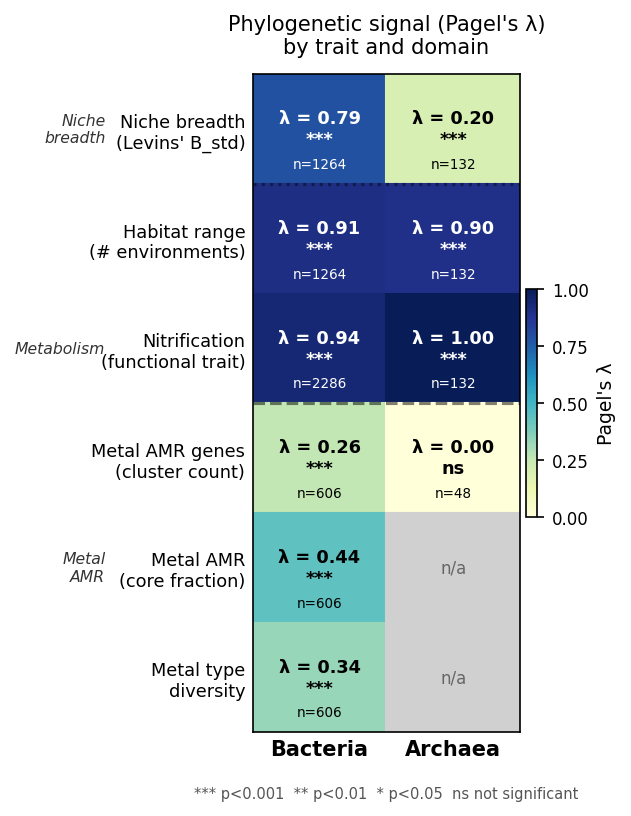

Saved figures/fig1_lambda_heatmap.png


In [5]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))

cmap   = plt.cm.YlGnBu
vmin, vmax = 0.0, 1.0

n_traits  = len(TRAIT_ORDER)
n_domains = len(DOMAINS)

for xi, domain in enumerate(DOMAINS):
    for yi, trait in enumerate(TRAIT_ORDER):
        lam_val = hm_lambda.loc[trait, domain]
        p_val   = hm_p.loc[trait, domain]
        n_val   = hm_n.loc[trait, domain]

        if np.isnan(lam_val):
            # No data — grey hatch
            rect = plt.Rectangle((xi - 0.5, (n_traits - 1 - yi) - 0.5),
                                   1, 1, color='#d0d0d0', zorder=1)
            ax.add_patch(rect)
            ax.text(xi, n_traits - 1 - yi, 'n/a',
                    ha='center', va='center', fontsize=8, color='#666666')
        else:
            color = cmap((lam_val - vmin) / (vmax - vmin))
            rect  = plt.Rectangle((xi - 0.5, (n_traits - 1 - yi) - 0.5),
                                    1, 1, color=color, zorder=1)
            ax.add_patch(rect)

            # λ value + significance
            stars = sig_stars(p_val)
            # Use white text for dark cells
            text_color = 'white' if lam_val > 0.6 else 'black'
            ax.text(xi, n_traits - 1 - yi,
                    f'λ = {lam_val:.2f}\n{stars}',
                    ha='center', va='center', fontsize=8.5,
                    color=text_color, fontweight='bold',
                    zorder=2)

            # n_taxa as small superscript below
            ax.text(xi, n_traits - 1 - yi - 0.32,
                    f'n={int(n_val)}',
                    ha='center', va='center', fontsize=6.5,
                    color=text_color, zorder=2)

# Axes formatting
ax.set_xlim(-0.5, n_domains - 0.5)
ax.set_ylim(-0.5, n_traits - 0.5)
ax.set_xticks(range(n_domains))
ax.set_xticklabels(DOMAINS, fontsize=10, fontweight='bold')
ax.set_yticks(range(n_traits))
ax.set_yticklabels(
    [TRAIT_LABELS[t] for t in reversed(TRAIT_ORDER)],
    fontsize=8.5
)
ax.tick_params(length=0)

# Group separator lines
ax.axhline(n_traits - 3.5, color='black', lw=1.5, ls='--', alpha=0.5)  # after nitrifier
ax.axhline(n_traits - 1.5, color='black', lw=1.5, ls=':',  alpha=0.4)  # after n_envs

# Group labels
ax.text(-0.55, n_traits - 1.0, 'Niche\nbreadth', ha='right', va='center',
        fontsize=7.5, color='#333333', style='italic',
        transform=ax.get_yaxis_transform())
ax.text(-0.55, n_traits - 3.0, 'Metabolism', ha='right', va='center',
        fontsize=7.5, color='#333333', style='italic',
        transform=ax.get_yaxis_transform())
ax.text(-0.55, n_traits - 5.0, 'Metal\nAMR', ha='right', va='center',
        fontsize=7.5, color='#333333', style='italic',
        transform=ax.get_yaxis_transform())

# Colorbar
sm = ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.04, pad=0.02)
cbar.set_label("Pagel's λ", fontsize=9)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])

ax.set_title("Phylogenetic signal (Pagel's λ)\nby trait and domain",
             fontsize=10, pad=10)
ax.text(0.5, -0.10,
        '*** p<0.001  ** p<0.01  * p<0.05  ns not significant',
        transform=ax.transAxes, ha='center', fontsize=7, color='#555555')

plt.tight_layout()
plt.savefig(FIGURES / 'fig1_lambda_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved figures/fig1_lambda_heatmap.png')

## 3. Figure 2: PGLS forest plot

Shows β ± 95% CI for all 6 simple PGLS models, grouped by response variable.  
Also overlays the multi-predictor model coefficients as triangles.

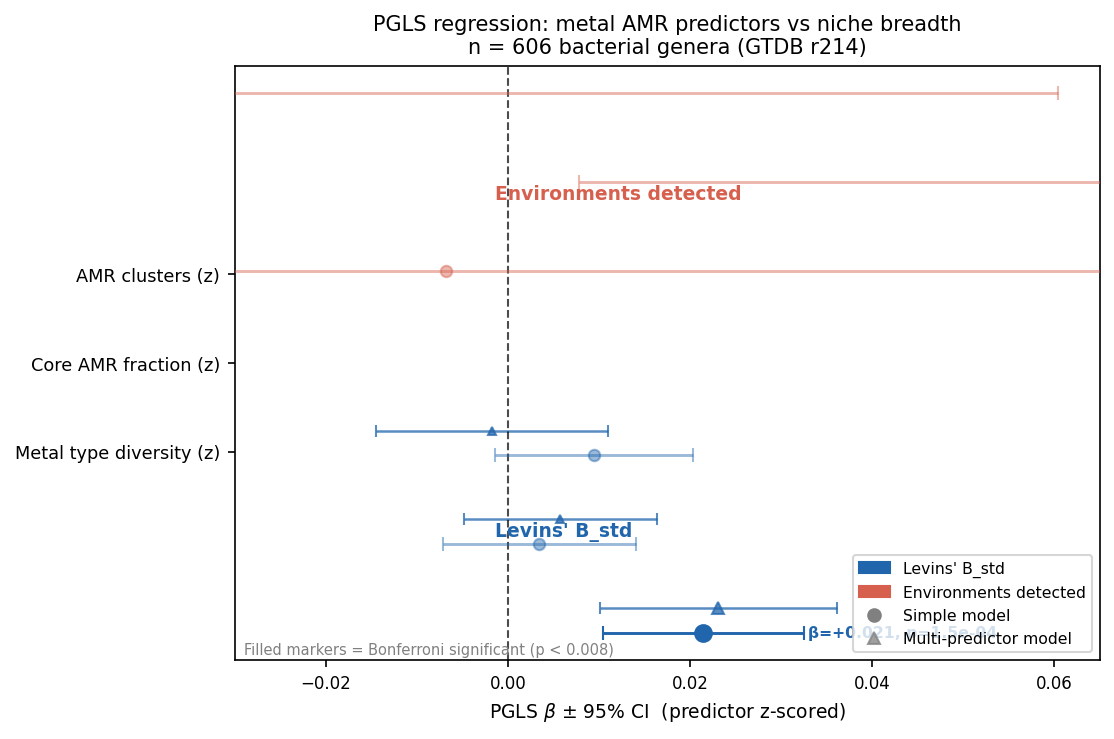

Saved figures/fig2_pgls_forest.png


In [6]:
fig, ax = plt.subplots(figsize=(7.5, 5.0))

# Layout: y positions for predictors, with gap between response groups
RESP_ORDER  = ['mean_levins_B_std', 'mean_n_envs']
PRED_ORDER  = ['mean_n_metal_amr_clusters_z',
               'mean_metal_core_fraction_z',
               'mean_n_metal_types_z']

RESP_COLORS = {'mean_levins_B_std': '#2166ac', 'mean_n_envs': '#d6604d'}
RESP_OFFSET = {'mean_levins_B_std': -0.14, 'mean_n_envs': +0.14}

# Build y positions: 3 predictors per group, gap of 0.6 between groups
GAP   = 0.8
ytick_pos    = []
ytick_labels = []

pred_y = {}   # (resp, pred) → y coordinate
for ri, resp in enumerate(RESP_ORDER):
    base = ri * (3 + GAP)
    for pi, pred in enumerate(PRED_ORDER):
        pred_y[(resp, pred)] = base + (2 - pi)   # top → bottom = AMR, core, types

# Draw model results
for resp in RESP_ORDER:
    col     = RESP_COLORS[resp]
    off     = RESP_OFFSET[resp]
    rsub    = pgls[pgls['response'] == resp].set_index('predictor')
    multi_r = multi[multi['response'] == resp].set_index('predictor') if 'response' in multi.columns else pd.DataFrame()

    for pred in PRED_ORDER:
        y = pred_y[(resp, pred)] + off
        if pred not in rsub.index:
            continue
        row = rsub.loc[pred]
        is_bonf = row['p_value'] < BONFERRONI

        # Simple model: circle
        ax.errorbar(
            row['beta'], y,
            xerr=1.96 * row['SE'],
            fmt='o', color=col,
            markersize=8 if is_bonf else 5.5,
            capsize=3.5, linewidth=1.4,
            alpha=1.0 if is_bonf else 0.45,
            zorder=3
        )

        # Annotation for Bonferroni-significant models
        if is_bonf:
            ax.text(
                row['beta'] + 1.96 * row['SE'] + 0.0005, y,
                f"β={row['beta']:+.3f}, p={row['p_value']:.1e}",
                va='center', ha='left', fontsize=7.5,
                color=col, fontweight='bold'
            )

        # Multi-predictor model: triangle
        if len(multi_r) > 0 and pred in multi_r.index:
            mrow  = multi_r.loc[pred]
            ym    = pred_y[(resp, pred)] - off  # swap offset for visual separation
            ax.errorbar(
                mrow['beta'], ym,
                xerr=1.96 * mrow['SE'],
                fmt='^', color=col,
                markersize=6 if mrow['p_value'] < 0.05 else 4,
                capsize=3, linewidth=1.2,
                alpha=0.75,
                zorder=2
            )

# Y-axis ticks: one per predictor, in the middle of the two response groups
for pi, pred in enumerate(PRED_ORDER):
    y_mid = np.mean([pred_y[(resp, pred)] for resp in RESP_ORDER])
    ytick_pos.append(y_mid)
    ytick_labels.append(PRED_LABELS[pred])

# Group labels on the right
for ri, resp in enumerate(RESP_ORDER):
    ys = [pred_y[(resp, p)] for p in PRED_ORDER]
    ax.text(ax.get_xlim()[1] if ax.get_xlim()[1] else 0.035,
            np.mean(ys),
            RESP_LABELS[resp], color=RESP_COLORS[resp],
            va='center', ha='left', fontsize=9, fontweight='bold',
            transform=ax.get_yaxis_transform())

ax.axvline(0, color='black', lw=1, ls='--', alpha=0.7)
ax.set_yticks(ytick_pos)
ax.set_yticklabels(ytick_labels, fontsize=8.5)
ax.set_xlabel(r'PGLS $\beta$ ± 95% CI  (predictor z-scored)', fontsize=9)
ax.set_title('PGLS regression: metal AMR predictors vs niche breadth\n'
             'n = 606 bacterial genera (GTDB r214)',
             fontsize=10)

# Legend
patches = [
    mpatches.Patch(color=RESP_COLORS[r], label=RESP_LABELS[r])
    for r in RESP_ORDER
]
circle_patch = plt.Line2D([0], [0], marker='o', color='gray',
                           label='Simple model', linestyle='none', markersize=6)
tri_patch    = plt.Line2D([0], [0], marker='^', color='gray',
                           label='Multi-predictor model', linestyle='none',
                           markersize=6, alpha=0.75)
ax.legend(handles=patches + [circle_patch, tri_patch],
          fontsize=7.5, loc='lower right')

ax.text(0.01, 0.01,
        f'Filled markers = Bonferroni significant (p < {BONFERRONI:.3f})',
        transform=ax.transAxes, fontsize=7, color='gray')

ax.set_xlim(-0.03, 0.065)
plt.tight_layout()
plt.savefig(FIGURES / 'fig2_pgls_forest.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved figures/fig2_pgls_forest.png')

## 4. Figure 3: Synthesis — 2-panel (λ heatmap + forest)

Single publication figure combining both panels with shared caption.

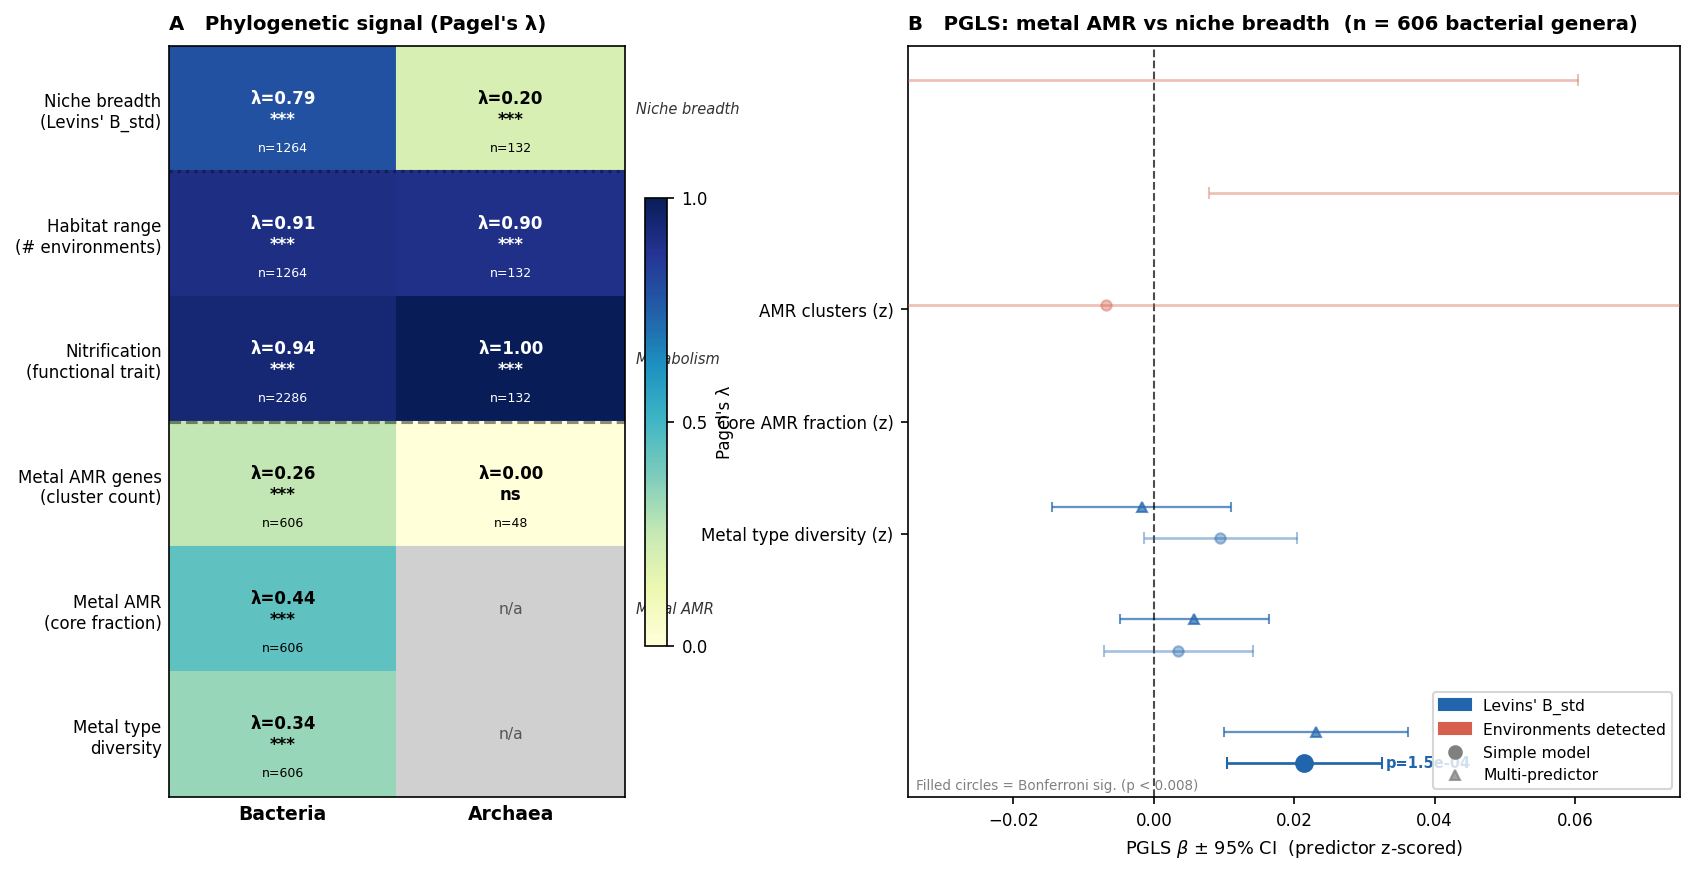

Saved figures/fig3_synthesis.png


In [7]:
fig = plt.figure(figsize=(13, 6.5))
gs  = gridspec.GridSpec(1, 2, figure=fig, width_ratios=[1, 1.55], wspace=0.38)

ax_hm  = fig.add_subplot(gs[0])
ax_fp  = fig.add_subplot(gs[1])

# ─── Panel A: λ heatmap ───────────────────────────────────────────────────
cmap = plt.cm.YlGnBu
vmin, vmax = 0.0, 1.0

for xi, domain in enumerate(DOMAINS):
    for yi, trait in enumerate(TRAIT_ORDER):
        lam_val = hm_lambda.loc[trait, domain]
        p_val   = hm_p.loc[trait, domain]
        n_val   = hm_n.loc[trait, domain]
        y_pos   = n_traits - 1 - yi

        if np.isnan(lam_val):
            rect = plt.Rectangle((xi - 0.5, y_pos - 0.5), 1, 1,
                                   color='#d0d0d0', zorder=1)
            ax_hm.add_patch(rect)
            ax_hm.text(xi, y_pos, 'n/a',
                       ha='center', va='center', fontsize=7.5, color='#555555')
        else:
            color      = cmap((lam_val - vmin) / (vmax - vmin))
            rect       = plt.Rectangle((xi - 0.5, y_pos - 0.5), 1, 1,
                                        color=color, zorder=1)
            ax_hm.add_patch(rect)
            text_color = 'white' if lam_val > 0.62 else 'black'
            ax_hm.text(xi, y_pos,
                       f'λ={lam_val:.2f}\n{sig_stars(p_val)}',
                       ha='center', va='center', fontsize=8,
                       color=text_color, fontweight='bold', zorder=2)
            ax_hm.text(xi, y_pos - 0.31, f'n={int(n_val)}',
                       ha='center', va='center', fontsize=6,
                       color=text_color, zorder=2)

ax_hm.set_xlim(-0.5, n_domains - 0.5)
ax_hm.set_ylim(-0.5, n_traits - 0.5)
ax_hm.set_xticks(range(n_domains))
ax_hm.set_xticklabels(DOMAINS, fontsize=9, fontweight='bold')
ax_hm.set_yticks(range(n_traits))
ax_hm.set_yticklabels(
    [TRAIT_LABELS[t] for t in reversed(TRAIT_ORDER)], fontsize=8
)
ax_hm.tick_params(length=0)
ax_hm.axhline(n_traits - 3.5, color='black', lw=1.5, ls='--', alpha=0.45)
ax_hm.axhline(n_traits - 1.5, color='black', lw=1.5, ls=':',  alpha=0.35)

# Group labels
for label, y in [('Niche breadth', n_traits - 1.0),
                  ('Metabolism',   n_traits - 3.0),
                  ('Metal AMR',    n_traits - 5.0)]:
    ax_hm.text(n_domains - 0.45, y, label,
               ha='left', va='center', fontsize=7, style='italic',
               color='#333333')

sm   = ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax_hm, orientation='vertical',
                    fraction=0.045, pad=0.04)
cbar.set_label("Pagel's λ", fontsize=8)
cbar.set_ticks([0, 0.5, 1.0])
ax_hm.set_title("A   Phylogenetic signal (Pagel's λ)", loc='left',
                fontsize=9.5, fontweight='bold', pad=8)

# ─── Panel B: PGLS forest ────────────────────────────────────────────────
for resp in RESP_ORDER:
    col  = RESP_COLORS[resp]
    off  = RESP_OFFSET[resp]
    rsub = pgls[pgls['response'] == resp].set_index('predictor')
    mr   = (multi[multi['response'] == resp].set_index('predictor')
            if 'response' in multi.columns else pd.DataFrame())

    for pred in PRED_ORDER:
        y        = pred_y[(resp, pred)] + off
        if pred not in rsub.index: continue
        row      = rsub.loc[pred]
        is_bonf  = row['p_value'] < BONFERRONI

        ax_fp.errorbar(
            row['beta'], y, xerr=1.96 * row['SE'],
            fmt='o', color=col,
            markersize=8 if is_bonf else 5,
            capsize=3, linewidth=1.3,
            alpha=1.0 if is_bonf else 0.4,
            zorder=3
        )
        if is_bonf:
            ax_fp.text(
                row['beta'] + 1.96 * row['SE'] + 0.0005, y,
                f"p={row['p_value']:.1e}",
                va='center', ha='left', fontsize=7,
                color=col, fontweight='bold'
            )

        if len(mr) > 0 and pred in mr.index:
            mrow = mr.loc[pred]
            ym   = pred_y[(resp, pred)] - off
            ax_fp.errorbar(
                mrow['beta'], ym, xerr=1.96 * mrow['SE'],
                fmt='^', color=col, markersize=5,
                capsize=2.5, linewidth=1.1, alpha=0.70, zorder=2
            )

ax_fp.axvline(0, color='black', lw=1, ls='--', alpha=0.7)
ax_fp.set_yticks(ytick_pos)
ax_fp.set_yticklabels(ytick_labels, fontsize=8)
ax_fp.set_xlabel(r'PGLS $\beta$ ± 95% CI  (predictor z-scored)', fontsize=8.5)
ax_fp.set_title('B   PGLS: metal AMR vs niche breadth  (n = 606 bacterial genera)',
                loc='left', fontsize=9.5, fontweight='bold', pad=8)

patches_resp = [mpatches.Patch(color=RESP_COLORS[r], label=RESP_LABELS[r])
                for r in RESP_ORDER]
mk_circle = plt.Line2D([0], [0], marker='o', color='gray', linestyle='none',
                        markersize=6, label='Simple model')
mk_tri    = plt.Line2D([0], [0], marker='^', color='gray', linestyle='none',
                        markersize=5, alpha=0.75, label='Multi-predictor')
ax_fp.legend(handles=patches_resp + [mk_circle, mk_tri],
             fontsize=7.5, loc='lower right')
ax_fp.text(0.01, 0.01,
           f'Filled circles = Bonferroni sig. (p < {BONFERRONI:.3f})',
           transform=ax_fp.transAxes, fontsize=6.5, color='gray')

ax_fp.set_xlim(-0.035, 0.075)

fig.savefig(FIGURES / 'fig3_synthesis.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved figures/fig3_synthesis.png')

## 5. Figure 4: Metal type diversity vs niche breadth (annotated scatter)

Shows the primary significant relationship from PGLS.  
Points coloured by phylum (top 8). PGLS regression line shown.  
Top-10 widest-niche genera annotated.

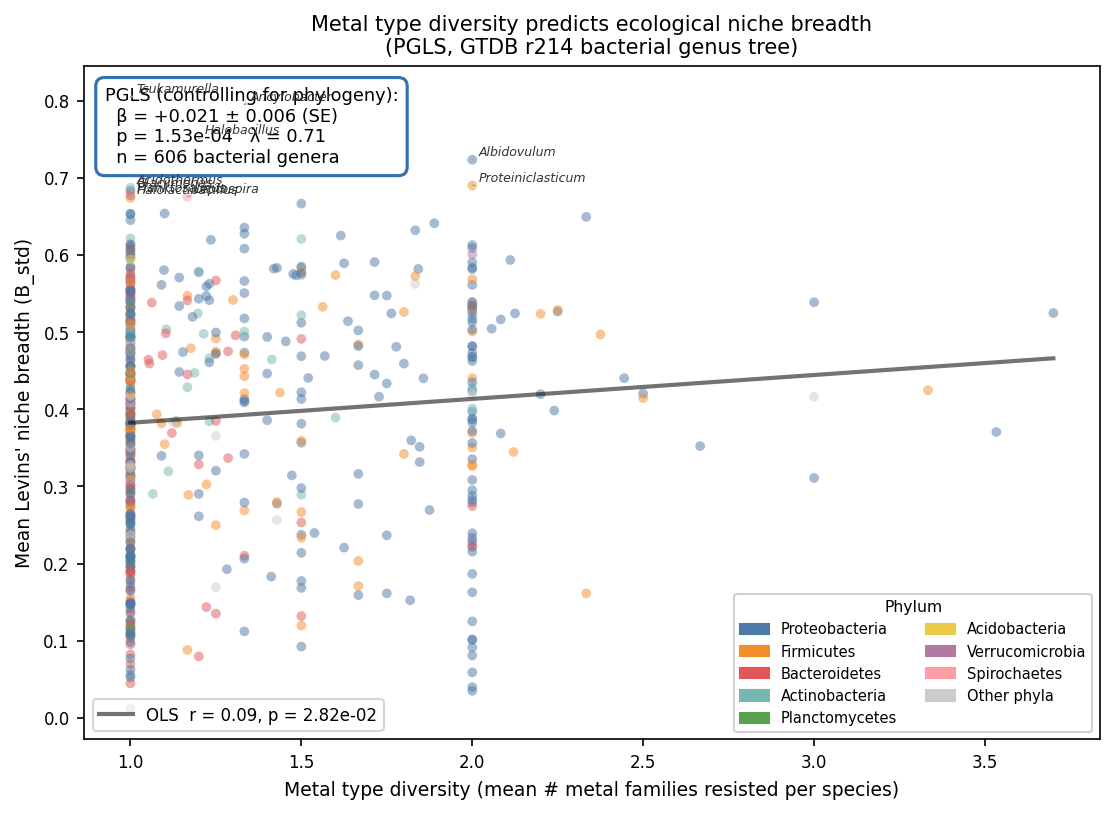

Saved figures/fig4_metal_types_scatter.png


In [8]:
# Colour by phylum
top_phyla = pgls_sub['phylum'].value_counts().head(8).index.tolist()
tab_colors = [
    '#4e79a7', '#f28e2b', '#e15759', '#76b7b2',
    '#59a14f', '#edc948', '#b07aa1', '#ff9da7'
]
pal = dict(zip(top_phyla, tab_colors))
pgls_sub = pgls_sub.copy()
pgls_sub['point_color'] = pgls_sub['phylum'].map(pal).fillna('#cccccc')

fig, ax = plt.subplots(figsize=(7.5, 5.5))

ax.scatter(
    pgls_sub['mean_n_metal_types'],
    pgls_sub['mean_levins_B_std'],
    c=pgls_sub['point_color'],
    alpha=0.50, s=22, linewidths=0, zorder=2
)

# OLS trendline
xv = pgls_sub['mean_n_metal_types']
yv = pgls_sub['mean_levins_B_std']
slope, intercept, r_ols, p_ols, _ = sp_stats.linregress(xv, yv)
xline = np.linspace(xv.min(), xv.max(), 200)
ax.plot(xline, slope * xline + intercept, 'k-', lw=2, alpha=0.55,
        label=f'OLS  r = {r_ols:.2f}, p = {p_ols:.2e}', zorder=3)

# PGLS β annotation box
pgls_row = pgls[
    (pgls['response'] == 'mean_levins_B_std') &
    (pgls['predictor'] == 'mean_n_metal_types_z')
].iloc[0]

ax.text(0.98, 0.97,
        f"PGLS (controlling for phylogeny):\n"
        f"  β = {pgls_row['beta']:+.3f} ± {pgls_row['SE']:.3f} (SE)\n"
        f"  p = {pgls_row['p_value']:.2e}   λ = {pgls_row['lambda']:.2f}\n"
        f"  n = {int(pgls_row['n_taxa'])} bacterial genera",
        transform=ax.transAxes, ha='right', va='top', fontsize=8.5,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                  edgecolor='#2166ac', linewidth=1.5, alpha=0.92))

# Annotate top-5 by B_std with directional offsets to avoid overlap
top5 = pgls_sub.nlargest(5, 'mean_levins_B_std').reset_index(drop=True)
offsets = [(-30, 6), (-35, -8), (5, 10), (-40, 12), (5, -10)]
for idx, (_, row) in enumerate(top5.iterrows()):
    ox, oy = offsets[idx]
    ax.annotate(
        row['genus_lower'].capitalize(),
        xy=(row['mean_n_metal_types'], row['mean_levins_B_std']),
        xytext=(ox, oy), textcoords='offset points',
        fontsize=6.5, color='#333333', style='italic',
        arrowprops=dict(arrowstyle='-', color='#aaaaaa', lw=0.8)
    )

ax.set_xlabel('Metal type diversity (mean # metal families resisted per species)',
              fontsize=9)
ax.set_ylabel("Mean Levins' niche breadth (B_std)", fontsize=9)
ax.set_title('Metal type diversity predicts ecological niche breadth\n'
             '(PGLS, GTDB r214 bacterial genus tree)',
             fontsize=10)

# Phylum legend
phylum_patches = [mpatches.Patch(color=c, label=p) for p, c in pal.items()]
phylum_patches.append(mpatches.Patch(color='#cccccc', label='Other phyla'))
leg1 = ax.legend(handles=phylum_patches, title='Phylum', fontsize=7,
                  title_fontsize=7.5, loc='lower right',
                  ncol=2, framealpha=0.9)
ax.add_artist(leg1)
ax.legend(fontsize=8, loc='lower left')

plt.tight_layout()
plt.savefig(FIGURES / 'fig4_metal_types_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved figures/fig4_metal_types_scatter.png')

## 6. Summary

### Figures produced

| File | Content |
|------|---------|
| `fig1_lambda_heatmap.png` | Pagel's λ heatmap — trait × domain |
| `fig2_pgls_forest.png` | Forest plot — all 6 simple PGLS models + multi-predictor triangles |
| `fig3_synthesis.png` | **Primary synthesis figure** — panels A (λ) + B (PGLS) |
| `fig4_metal_types_scatter.png` | Annotated scatter — metal type diversity vs Levins' B_std |

### Story told by the figures

**λ heatmap (Panel A)**:  
- Niche breadth and habitat type are strongly conserved in Bacteria (λ = 0.79, 0.91) and Archaea (λ = 0.20, 0.90). Bacteria that diversify ecologically tend to come from lineages already predisposed to broad niches.  
- Nitrification is maximally conserved (λ = 0.94–1.00) — a signature of ancient metabolic entrenchment.  
- Metal AMR traits show intermediate phylogenetic signal (λ = 0.26–0.44), indicating a mixture of vertical inheritance and horizontal gene transfer.  
- Archaea: metal AMR shows no phylogenetic signal (λ ≈ 0, n = 48) — possibly HGT-driven or too few sampled genera for detection.

**PGLS forest (Panel B)**:  
- **Metal type diversity is the only predictor that survives Bonferroni correction** (β = +0.021, p = 1.5×10⁻⁴) for Levins' B_std.  
- The effect is robust in the multi-predictor model (β = +0.023, p = 5.5×10⁻⁴), where metal AMR cluster count and core fraction are non-significant.  
- The positive direction means genera resistant to *more types* of metals occupy broader ecological niches — consistent with a **metabolic versatility / metal-contaminated habitat** co-evolution hypothesis.

**Scatter (Figure 4)**:  
- The relationship is modest in raw data (OLS r ≈ 0.21) but the PGLS β is significant because the test controls for the moderate phylogenetic signal in the predictor (λ = 0.34 from NB04).

### Next step
- Run `/synthesize` to draft the project `REPORT.md` using these figure outputs.

In [9]:
figs = sorted(FIGURES.glob('fig*.png'))
print('=== Figures generated by NB06 ===')
for f in figs:
    size_kb = f.stat().st_size // 1024
    print(f'  {f.name:<40s}  {size_kb:>5d} KB')

=== Figures generated by NB06 ===
  fig1_lambda_heatmap.png                     178 KB
  fig2_pgls_forest.png                        136 KB
  fig3_synthesis.png                          265 KB
  fig4_metal_types_scatter.png                334 KB
